# Tutorial 1: Python Basics for Data Analysis

**CS Statistics Course | Week 1-2**

---

## Welcome to Data Analysis!

In Lectures 1-2, you learned what data science is and why it matters. You saw that data scientists work with:
- **Categorical data** (like programming languages, company sizes)
- **Numerical data** (like salaries, years of experience)
- **Data summaries** (mean, median, standard deviation, quantiles)
- **Data visualization** (histograms, bar charts, scatter plots)

In this tutorial, you'll **get hands-on** with the Python tools that let you do this analysis yourself. By the end of 2 hours, you'll be able to load real data, explore it, summarize it, and visualize it — exactly like a data scientist.

### The Case Study: Analyzing Software Developer Survey Data

Imagine you work at a tech recruitment company and want to understand the software developer job market. You have survey data from 500 developers around the world with information about:
- Their primary programming language
- Years of experience
- Annual salary
- Job satisfaction
- Company size (startup, small, medium, large, enterprise)
- Remote work status (yes, no, hybrid)
- Weekly hours worked
- Number of projects
- Country

**Your goal:** Use Python to answer real questions like:
- What's the average salary for developers with 5 years of experience?
- Do developers who work remotely have higher job satisfaction?
- How do salaries differ across programming languages?
- What's the relationship between experience and salary?

Let's get started!


## Setup: Import the Libraries

We'll use four key libraries for data analysis:
- **pandas** ([documentation](https://pandas.pydata.org/docs/)) — for loading and manipulating data
- **numpy** ([documentation](https://numpy.org/doc/)) — for numerical computations
- **matplotlib** ([documentation](https://matplotlib.org/)) — for basic plotting
- **seaborn** ([documentation](https://seaborn.pydata.org/)) — for statistical visualization


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

---

## Section 1: Loading and Exploring Data (~15 min)

### Why This Matters (From Lecture)
Before you can analyze data, you need to understand what you're working with. In lecture, you learned that every dataset has:
- **Rows** (observations/records) — each row is one developer
- **Columns** (features/variables) — each column is a characteristic like salary or experience

Let's load the developer survey data and explore it.


### Loading Data with `pd.read_csv()`

The most common way to load data into Python is from a CSV (comma-separated values) file.

Reference: [pd.read_csv documentation](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)


In [2]:
# Load the developer survey dataset
df = pd.read_csv('developer_survey.csv')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 500 rows, 10 columns


### Exploring the Dataset

Use these methods to understand your data:
- `df.head()` — see the first few rows
- `df.shape` — get the dimensions (rows, columns)
- `df.dtypes` — check data types (int, float, object/string)
- `df.describe()` — get summary statistics
- `df.info()` — get detailed information including missing values


In [3]:
# See the first 5 rows
df.head()

,developer_id,primary_language,years_experience,annual_salary,job_satisfaction,company_size,remote_work,weekly_hours,num_projects,country
0,362,JavaScript,5,47909.0,6.0,medium,yes,28.0,2,India
1,74,C++,8,62777.0,3.0,large,hybrid,26.0,1,India
2,375,Python,18,66011.0,5.0,medium,no,NaN,5,India
3,156,Python,19,103941.0,6.0,large,no,49.0,9,UK
4,105,Rust,15,103425.0,5.0,medium,yes,59.0,4,UK


In [4]:
# Check the shape (rows, columns)
print(f"Dataset shape: {df.shape}")
print(f"Number of developers: {df.shape[0]}")
print(f"Number of features per developer: {df.shape[1]}")

Dataset shape: (500, 10)
Number of developers: 500
Number of features per developer: 10


In [5]:
# Check data types
print("Data types:")
print(df.dtypes)
print("\nNote:")
print("- int64: integers (whole numbers)")
print("- float64: floating-point numbers (with decimals) — may contain NaN values")
print("- object: strings/text data")

Data types:
developer_id          int64
primary_language     object
years_experience      int64
annual_salary       float64
job_satisfaction    float64
company_size         object
remote_work          object
weekly_hours        float64
num_projects          int64
country              object
dtype: object

Note:
- int64: integers (whole numbers)
- float64: floating-point numbers (with decimals) — may contain NaN values
- object: strings/text data


In [6]:
# Get summary statistics (matches what you learned in lecture!)
df.describe()

,developer_id,years_experience,annual_salary,job_satisfaction,weekly_hours,num_projects
count,500.000000,500.000000,490.000000,490.000000,490.000000,500.000000
mean,250.500000,12.574000,92463.361224,5.430612,40.544898,7.864000
std,144.481833,7.404741,26164.698320,2.945358,12.031784,4.143409
min,1.000000,1.000000,36485.000000,1.000000,20.000000,1.000000
25%,125.750000,6.000000,72277.500000,3.000000,30.000000,4.000000
50%,250.500000,13.000000,91714.500000,5.000000,40.500000,8.000000
75%,375.250000,19.000000,111958.750000,8.000000,51.000000,11.000000
max,500.000000,25.000000,162866.000000,10.000000,60.000000,15.000000


In [7]:
# Get detailed info including missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   developer_id      500 non-null    int64  
 1   primary_language  500 non-null    object 
 2   years_experience  500 non-null    int64  
 3   annual_salary     490 non-null    float64
 4   job_satisfaction  490 non-null    float64
 5   company_size      500 non-null    object 
 6   remote_work       500 non-null    object 
 7   weekly_hours      490 non-null    float64
 8   num_projects      500 non-null    int64  
 9   country           500 non-null    object 
dtypes: float64(3), int64(3), object(4)
memory usage: 39.2+ KB


### Selecting Columns

To work with a specific column, you have two options:
- `df["column_name"]` (always works)
- `df.column_name` (works if column name has no spaces)

Reference: [Indexing and selecting data](https://pandas.pydata.org/docs/user_guide/indexing.html)


In [8]:
# Select a single column — returns a Series
languages = df['primary_language']
print(f"Type: {type(languages)}")
print(f"\nFirst 5 values:")
print(languages.head())

Type: <class 'pandas.core.series.Series'>

First 5 values:
0    JavaScript
1           C++
2        Python
3        Python
4          Rust
Name: primary_language, dtype: object


In [9]:
# Select multiple columns — returns a DataFrame
subset = df[['primary_language', 'years_experience', 'annual_salary']]
print(f"Type: {type(subset)}")
print(f"\nShape: {subset.shape}")
print(f"\nFirst few rows:")
print(subset.head())

Type: <class 'pandas.core.frame.DataFrame'>

Shape: (500, 3)

First few rows:
  primary_language  years_experience  annual_salary
0       JavaScript                 5        47909.0
1              C++                 8        62777.0
2           Python                18        66011.0
3           Python                19       103941.0
4             Rust                15       103425.0


### Selecting Rows

To select specific rows, use:
- `df.loc[row_label]` — select by label (row index)
- `df.iloc[row_position]` — select by integer position

Reference: [loc and iloc documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html)


In [10]:
# Select the first developer (row 0)
first_dev = df.iloc[0]
print("First developer's data:")
print(first_dev)
print(f"\nType: {type(first_dev)}")

First developer's data:
developer_id               362
primary_language    JavaScript
years_experience             5
annual_salary          47909.0
job_satisfaction           6.0
company_size            medium
remote_work                yes
weekly_hours              28.0
num_projects                 2
country                  India
Name: 0, dtype: object

Type: <class 'pandas.core.series.Series'>


In [11]:
# Select the first 10 rows
first_10 = df.iloc[0:10]
print(f"First 10 developers (shape: {first_10.shape}):")
print(first_10)

First 10 developers (shape: (10, 10)):
   developer_id primary_language  years_experience  annual_salary  \
0           362       JavaScript                 5        47909.0   
1            74              C++                 8        62777.0   
2           375           Python                18        66011.0   
3           156           Python                19       103941.0   
4           105             Rust                15       103425.0   
5           395             Java                 8        81443.0   
6           378           Python                 7        63920.0   
7           125           Python                20       120531.0   
8            69           Python                 4        67688.0   
9           451              C++                11        87116.0   

   job_satisfaction company_size remote_work  weekly_hours  num_projects  \
0               6.0       medium         yes          28.0             2   
1               3.0        large      hybrid     

In [12]:
# Select a specific cell: developer at row 5, 'annual_salary' column
salary_row5 = df.loc[5, 'annual_salary']
print(f"Developer at index 5's salary: ${salary_row5:,.0f}")

Developer at index 5's salary: $81,443


### EXERCISES: Section 1

**Exercise 1.1:** How many columns are in the dataset, and what is the name of the 5th column?


In [13]:
# Solution
num_cols = df.shape[1]
fifth_col = df.columns[4]  # 0-indexed, so 4 is the 5th column
print(f"Number of columns: {num_cols}")
print(f"5th column name: {fifth_col}")

Number of columns: 10
5th column name: job_satisfaction


**Exercise 1.2:** Extract the `years_experience` column and show the first 10 values.


In [14]:
# Solution
experience = df['years_experience']
print(experience.head(10))

0     5
1     8
2    18
3    19
4    15
5     8
6     7
7    20
8     4
9    11
Name: years_experience, dtype: int64


**Exercise 1.3:** Select the rows from index 100 to 105 and show the `developer_id`, `primary_language`, and `annual_salary` columns.


In [15]:
# Solution
subset_rows = df.iloc[100:106][['developer_id', 'primary_language', 'annual_salary']]
print(subset_rows)

     developer_id primary_language  annual_salary
100           250             Rust       111523.0
101           434           Python       113850.0
102            20             Java       129245.0
103           323       JavaScript        70131.0
104           333           Python        93348.0
105            57           Python        87762.0


---

## Section 2: Filtering and Transforming Data (~20 min)

### Why This Matters (From Lecture)
Real data is messy and includes everything. To answer specific questions, you need to:
- **Filter** the data to focus on subsets (e.g., "only developers with 10+ years of experience")
- **Transform** the data (e.g., convert salary to a different unit, standardize values)
- **Handle missing data** (some surveys have incomplete responses)

Let's master these techniques.


### Boolean Masking: Filtering with Conditions

Use boolean conditions to select rows that meet specific criteria.

Reference: [Boolean indexing](https://pandas.pydata.org/docs/user_guide/indexing.html#boolean-indexing)


In [16]:
# Create a boolean mask for developers with 10+ years of experience
experienced = df['years_experience'] >= 10
print(f"Type of mask: {type(experienced)}")
print(f"\nFirst 10 values (True = meets condition, False = doesn't):")
print(experienced.head(10))
print(f"\nNumber of developers with 10+ years: {experienced.sum()}")

Type of mask: <class 'pandas.core.series.Series'>

First 10 values (True = meets condition, False = doesn't):
0    False
1    False
2     True
3     True
4     True
5    False
6    False
7     True
8    False
9     True
Name: years_experience, dtype: bool

Number of developers with 10+ years: 306


In [17]:
# Use the mask to filter the dataframe
experienced_devs = df[experienced]
print(f"Shape of filtered data: {experienced_devs.shape}")
print(f"\nFirst few experienced developers:")
print(experienced_devs.head())

Shape of filtered data: (306, 10)

First few experienced developers:
   developer_id primary_language  years_experience  annual_salary  \
2           375           Python                18        66011.0   
3           156           Python                19       103941.0   
4           105             Rust                15       103425.0   
7           125           Python                20       120531.0   
9           451              C++                11        87116.0   

   job_satisfaction company_size remote_work  weekly_hours  num_projects  \
2               5.0       medium          no           NaN             5   
3               6.0        large          no          49.0             9   
4               5.0       medium         yes          59.0             4   
7               2.0        small          no          58.0             6   
9              10.0       medium          no          42.0            10   

   country  
2    India  
3       UK  
4       UK  
7      

In [18]:
# You can combine filter and selection in one line
result = df[df['years_experience'] >= 10][['primary_language', 'years_experience', 'annual_salary']]
print(f"Developers with 10+ years (showing languages, experience, salary):")
print(result.head())

Developers with 10+ years (showing languages, experience, salary):
  primary_language  years_experience  annual_salary
2           Python                18        66011.0
3           Python                19       103941.0
4             Rust                15       103425.0
7           Python                20       120531.0
9              C++                11        87116.0


### Combining Multiple Conditions

Use `&` (AND), `|` (OR), and `~` (NOT) to combine conditions.

**Important:** Always wrap conditions in parentheses!


In [19]:
# AND: Developers with 10+ years AND working in Python
experienced_python = df[(df['years_experience'] >= 10) & (df['primary_language'] == 'Python')]
print(f"Experienced Python developers: {len(experienced_python)}")
print(f"\nAverage salary: ${experienced_python['annual_salary'].mean():,.0f}")
print(f"\nFirst few:")
print(experienced_python[['primary_language', 'years_experience', 'annual_salary']].head())

Experienced Python developers: 81

Average salary: $96,523

First few:
   primary_language  years_experience  annual_salary
2            Python                18        66011.0
3            Python                19       103941.0
7            Python                20       120531.0
14           Python                13        85490.0
26           Python                25       111092.0


In [20]:
# OR: Developers using Rust OR Go
rust_or_go = df[(df['primary_language'] == 'Rust') | (df['primary_language'] == 'Go')]
print(f"Developers using Rust or Go: {len(rust_or_go)}")
print(f"\nLanguage breakdown:")
print(rust_or_go['primary_language'].value_counts())# Your code here
# OR: Developers using Rust OR Go

Developers using Rust or Go: 83

Language breakdown:
primary_language
Rust    53
Go      30
Name: count, dtype: int64


In [21]:
# NOT: Developers NOT working remotely
not_remote = df[~(df['remote_work'] == 'yes')]
print(f"Developers not working remotely: {len(not_remote)}")
print(f"\nRemote work breakdown:")
print(not_remote['remote_work'].value_counts())

Developers not working remotely: 329

Remote work breakdown:
remote_work
hybrid    183
no        146
Name: count, dtype: int64


### Transforming Data with `.apply()`

The `.apply()` method lets you apply a function to every value in a column.

Reference: [apply documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.apply.html)


In [22]:
# Example: Convert salary from dollars to thousands of dollars
salary_in_thousands = df['annual_salary'].apply(lambda x: x / 1000 if pd.notna(x) else np.nan)
print(f"Original salary (first 5): {df['annual_salary'].head().values}")
print(f"Converted (first 5): {salary_in_thousands.head().values}")

Original salary (first 5): [ 47909.  62777.  66011. 103941. 103425.]
Converted (first 5): [ 47.909  62.777  66.011 103.941 103.425]


In [23]:
# Define a function and use it with apply
def salary_bracket(salary):
    """Assign salary to a bracket."""
    if pd.isna(salary):
        return 'Unknown'
    elif salary < 60000:
        return 'Junior'
    elif salary < 100000:
        return 'Mid-level'
    else:
        return 'Senior'

df['salary_bracket'] = df['annual_salary'].apply(salary_bracket)
print(f"Salary bracket distribution:")
print(df['salary_bracket'].value_counts())
print(f"\nFirst few rows with new column:")
print(df[['annual_salary', 'salary_bracket']].head(10))

Salary bracket distribution:
salary_bracket
Mid-level    243
Senior       192
Junior        55
Unknown       10
Name: count, dtype: int64

First few rows with new column:
   annual_salary salary_bracket
0        47909.0         Junior
1        62777.0      Mid-level
2        66011.0      Mid-level
3       103941.0         Senior
4       103425.0         Senior
5        81443.0      Mid-level
6        63920.0      Mid-level
7       120531.0         Senior
8        67688.0      Mid-level
9        87116.0      Mid-level


### Handling Missing Values

Real data often has missing values. Learn to detect and handle them.

Reference: [Working with missing data](https://pandas.pydata.org/docs/user_guide/missing_data.html)


In [24]:
# Check for missing values
print("Missing values per column:")
missing_counts = df.isna().sum()
print(missing_counts[missing_counts > 0])
print(f"\nPercentage of data that's missing:")
missing_pct = (df.isna().sum() / len(df) * 100)
print(missing_pct[missing_pct > 0])

Missing values per column:
annual_salary       10
job_satisfaction    10
weekly_hours        10
dtype: int64

Percentage of data that's missing:
annual_salary       2.0
job_satisfaction    2.0
weekly_hours        2.0
dtype: float64


In [25]:
# Filter to only rows with non-null salary
complete_salary = df[df['annual_salary'].notna()]
print(f"Rows with valid salary data: {len(complete_salary)} out of {len(df)}")

# Drop all rows with ANY missing values
complete = df.dropna()
print(f"Rows with complete data (no missing): {len(complete)} out of {len(df)}")

Rows with valid salary data: 490 out of 500
Rows with complete data (no missing): 470 out of 500


In [26]:
# Fill missing values with a specific value (e.g., median)
df_filled = df.copy()
df_filled.fillna({'annual_salary': df['annual_salary'].median()}, inplace=True)
df_filled.fillna({'job_satisfaction' : df['job_satisfaction'].median()}, inplace=True)
df_filled.fillna({'weekly_hours': df['weekly_hours'].median()}, inplace=True)

print(f"Missing values after filling:")
print(df_filled.isna().sum().sum())  # Total missing values

Missing values after filling:
0


### EXERCISES: Section 2

**Exercise 2.1:** Filter the dataset to show only developers from the US who work remotely (full-time remote, not hybrid).


In [27]:
# Solution
us_remote = df[(df['country'] == 'US') & (df['remote_work'] == 'yes')]
print(f"US developers working fully remote: {len(us_remote)}")
print(f"\nFirst few:")
print(us_remote[['country', 'remote_work', 'annual_salary']].head())

US developers working fully remote: 38

First few:
   country remote_work  annual_salary
23      US         yes       104800.0
28      US         yes       134711.0
70      US         yes       102391.0
80      US         yes       144356.0
85      US         yes       121103.0


**Exercise 2.2:** Create a new column `experience_level` that assigns developers to "Beginner" (< 5 years), "Intermediate" (5-15 years), or "Expert" (15+ years).


In [28]:
# Solution
def experience_level(years):
    if years < 5:
        return 'Beginner'
    elif years < 15:
        return 'Intermediate'
    else:
        return 'Expert'

df['experience_level'] = df['years_experience'].apply(experience_level)
print(f"Experience level distribution:")
print(df['experience_level'].value_counts())
print(f"\nExample:")
print(df[['years_experience', 'experience_level']].head(10))

Experience level distribution:
experience_level
Expert          212
Intermediate    200
Beginner         88
Name: count, dtype: int64

Example:
   years_experience experience_level
0                 5     Intermediate
1                 8     Intermediate
2                18           Expert
3                19           Expert
4                15           Expert
5                 8     Intermediate
6                 7     Intermediate
7                20           Expert
8                 4         Beginner
9                11     Intermediate


**Exercise 2.3:** How many developers have missing data for job_satisfaction? What percentage of the dataset is this?


In [29]:
# Solution
missing_satisfaction = df['job_satisfaction'].isna().sum()
pct_missing = missing_satisfaction / len(df) * 100
print(f"Missing job satisfaction data: {missing_satisfaction} developers")
print(f"Percentage: {pct_missing:.1f}%")

Missing job satisfaction data: 10 developers
Percentage: 2.0%


---

## Section 3: Data Summaries (~20 min)

### Why This Matters (From Lecture)
In lecture, you learned about **summary statistics**: mean, median, standard deviation, min, max, quantiles. These help you understand the "typical" value in your data and how spread out it is.

Now you'll compute them yourself!


### Basic Summary Statistics

Pandas provides many methods to summarize numerical data.

Reference: [Descriptive statistics](https://pandas.pydata.org/docs/user_guide/basics.html#descriptive-statistics)


In [30]:
# Get individual statistics
salary_data = df['annual_salary'].dropna()  # Remove NaN for these calculations

print("Salary Statistics:")
print(f"  Mean: ${salary_data.mean():,.0f}")
print(f"  Median: ${salary_data.median():,.0f}")
print(f"  Std Dev: ${salary_data.std():,.0f}")
print(f"  Min: ${salary_data.min():,.0f}")
print(f"  Max: ${salary_data.max():,.0f}")
print(f"  25th percentile (Q1): ${salary_data.quantile(0.25):,.0f}")
print(f"  50th percentile (Q2/Median): ${salary_data.quantile(0.50):,.0f}")
print(f"  75th percentile (Q3): ${salary_data.quantile(0.75):,.0f}")

Salary Statistics:
  Mean: $92,463
  Median: $91,714
  Std Dev: $26,165
  Min: $36,485
  Max: $162,866
  25th percentile (Q1): $72,278
  50th percentile (Q2/Median): $91,714
  75th percentile (Q3): $111,959


In [31]:
# The .describe() method gives you most of these at once
df['annual_salary'].describe()

count       490.000000
mean      92463.361224
std       26164.698320
min       36485.000000
25%       72277.500000
50%       91714.500000
75%      111958.750000
max      162866.000000
Name: annual_salary, dtype: float64

In [32]:
# Get describe for multiple columns
df[['years_experience', 'annual_salary', 'job_satisfaction']].describe()

,years_experience,annual_salary,job_satisfaction
count,500.000000,490.000000,490.000000
mean,12.574000,92463.361224,5.430612
std,7.404741,26164.698320,2.945358
min,1.000000,36485.000000,1.000000
25%,6.000000,72277.500000,3.000000
50%,13.000000,91714.500000,5.000000
75%,19.000000,111958.750000,8.000000
max,25.000000,162866.000000,10.000000


### Grouped Summaries with `.groupby()`

One of the most powerful tools in pandas! Group data by a categorical variable, then compute statistics for each group.

Reference: [groupby documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html)


In [33]:
# Group by primary_language and get mean salary for each
salary_by_language = df.groupby('primary_language')['annual_salary'].mean().sort_values(ascending=False)
print("Average salary by programming language:")
for lang, salary in salary_by_language.items():
    print(f"  {lang}: ${salary:,.0f}")

Average salary by programming language:
  Go: $101,661
  Rust: $101,127
  C++: $97,360
  JavaScript: $90,752
  Java: $90,528
  Python: $87,048


In [34]:
# Get multiple statistics at once
language_stats = df.groupby('primary_language')['annual_salary'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max')
])
print("\nDetailed salary statistics by language:")
print(language_stats.round(0))


Detailed salary statistics by language:
                  count      mean    median      std      min       max
primary_language                                                       
C++                  69   97360.0   94437.0  26576.0  44180.0  153788.0
Go                   30  101661.0   99044.0  25822.0  57879.0  151943.0
Java                 91   90528.0   87462.0  25958.0  37070.0  146619.0
JavaScript          119   90752.0   91247.0  26123.0  36485.0  141954.0
Python              128   87048.0   84579.0  23454.0  44494.0  147570.0
Rust                 53  101127.0  103425.0  29008.0  42750.0  162866.0


In [35]:
# Group by company size
salary_by_company = df.groupby('company_size')['annual_salary'].agg(['count', 'mean', 'median'])
print("\nSalary statistics by company size:")
print(salary_by_company.round(0))


Salary statistics by company size:
              count      mean    median
company_size                           
enterprise       76  105381.0  104702.0
large           126   97686.0   97212.0
medium          118   87713.0   85966.0
small            93   90209.0   89025.0
startup          77   81170.0   75811.0


In [36]:
# Group by remote work status
remote_stats = df.groupby('remote_work')[['annual_salary', 'job_satisfaction']].agg(['mean', 'median'])
print("\nSalary and satisfaction by remote work status:")
print(remote_stats.round(0))


Salary and satisfaction by remote work status:
            annual_salary          job_satisfaction       
                     mean   median             mean median
remote_work                                               
hybrid            96228.0  98240.0              5.0    5.0
no                89027.0  87304.0              5.0    5.0
yes               91390.0  87762.0              6.0    6.0


### Categorical Data: `.value_counts()`

For categorical columns, use `.value_counts()` to see the frequency of each category.


In [37]:
# Count how many developers use each language
language_counts = df['primary_language'].value_counts()
print("Number of developers by language:")
print(language_counts)
print(f"\nTotal: {language_counts.sum()}")

Number of developers by language:
primary_language
Python        130
JavaScript    123
Java           93
C++            71
Rust           53
Go             30
Name: count, dtype: int64

Total: 500


In [38]:
# Get percentages
language_pct = df['primary_language'].value_counts(normalize=True) * 100
print("Percentage of developers by language:")
for lang, pct in language_pct.items():
    print(f"  {lang}: {pct:.1f}%")

Percentage of developers by language:
  Python: 26.0%
  JavaScript: 24.6%
  Java: 18.6%
  C++: 14.2%
  Rust: 10.6%
  Go: 6.0%


In [39]:
# Cross-tabulation: see the breakdown of two categorical variables
# Note: this is just a contingency table!
remote_by_country = pd.crosstab(df['country'], df['remote_work'])
print("\nNumber of developers by country and remote work status:")
print(remote_by_country)


Number of developers by country and remote work status:
remote_work  hybrid  no  yes
country                     
Canada           24  25   24
Germany          32  15   25
India            38  34   42
Netherlands      14  12   14
UK               23  27   28
US               52  33   38


### EXERCISES: Section 3

**Exercise 3.1:** What is the median number of weekly hours worked? What about by experience level (using the column you created in Section 2)?


In [40]:
# Solution
overall_median = df['weekly_hours'].median()
print(f"Overall median weekly hours: {overall_median}")

print(f"\nMedian weekly hours by experience level:")
by_experience = df.groupby('experience_level')['weekly_hours'].median()
print(by_experience)

Overall median weekly hours: 40.5

Median weekly hours by experience level:
experience_level
Beginner        40.5
Expert          39.0
Intermediate    41.0
Name: weekly_hours, dtype: float64


**Exercise 3.2:** Which country has the highest average job satisfaction? Which has the lowest?


In [41]:
# Solution
satisfaction_by_country = df.groupby('country')['job_satisfaction'].mean().sort_values(ascending=False)
print("Average job satisfaction by country:")
print(satisfaction_by_country.round(2))

print(f"\nHighest: {satisfaction_by_country.idxmax()} ({satisfaction_by_country.max():.2f})")
print(f"Lowest: {satisfaction_by_country.idxmin()} ({satisfaction_by_country.min():.2f})")

Average job satisfaction by country:
country
Germany        5.87
Canada         5.50
UK             5.50
US             5.43
India          5.42
Netherlands    4.41
Name: job_satisfaction, dtype: float64

Highest: Germany (5.87)
Lowest: Netherlands (4.41)


**Exercise 3.3:** Create a cross-tabulation showing the count of developers for each combination of `experience_level` and `company_size`.


In [42]:
# Solution
experience_company = pd.crosstab(df['experience_level'], df['company_size'])
print("Developer count by experience level and company size:")
print(experience_company)

Developer count by experience level and company size:
company_size      enterprise  large  medium  small  startup
experience_level                                           
Beginner                  12     27      19     13       17
Expert                    33     60      47     45       27
Intermediate              32     42      57     35       34


---

## Section 4: Basic Visualization (~20 min)

### Why This Matters (From Lecture)
"A picture is worth a thousand words." Visualization was a key topic in lecture because:
- Patterns jump out visually
- You can spot outliers and distributions
- It's easier to communicate findings to others

Now you'll create the plots you saw in lecture!


### Histograms: Visualizing Numerical Distributions

A histogram shows how a numerical variable is distributed.

Reference: [matplotlib.pyplot.hist](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html)


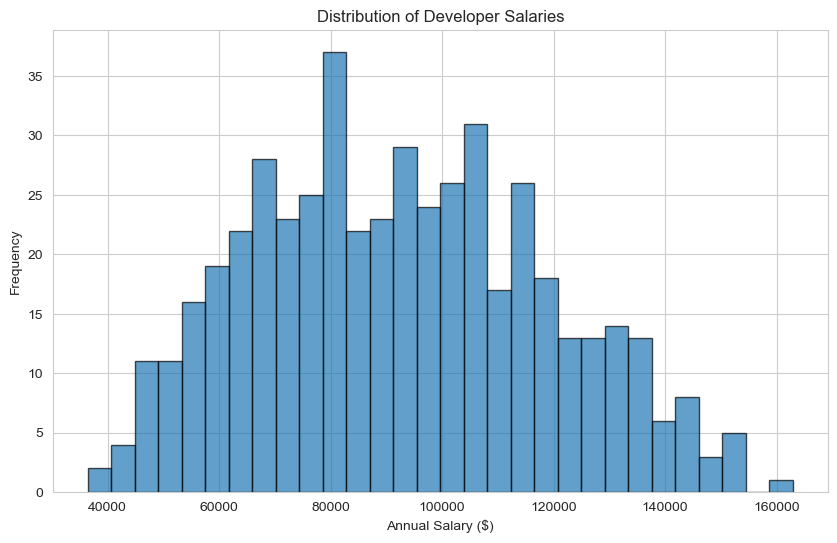

In [43]:
# Simple histogram of salaries
plt.figure(figsize=(10, 6))
df['annual_salary'].dropna().hist(bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Annual Salary ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Developer Salaries')
plt.show()

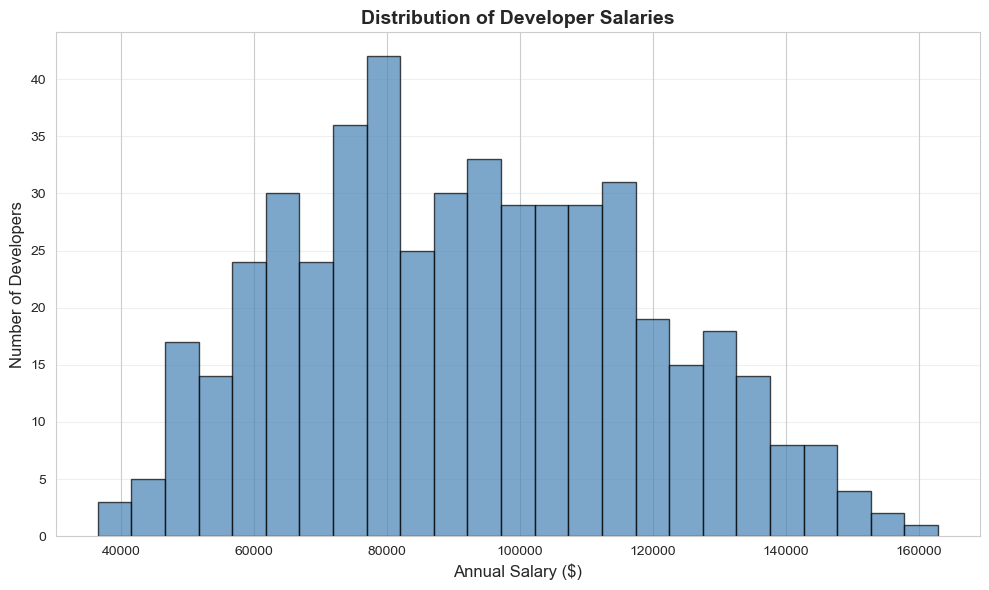

In [44]:
# Histogram with more control using matplotlib
plt.figure(figsize=(10, 6))
plt.hist(df['annual_salary'].dropna(), bins=25, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Annual Salary ($)', fontsize=12)
plt.ylabel('Number of Developers', fontsize=12)
plt.title('Distribution of Developer Salaries', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

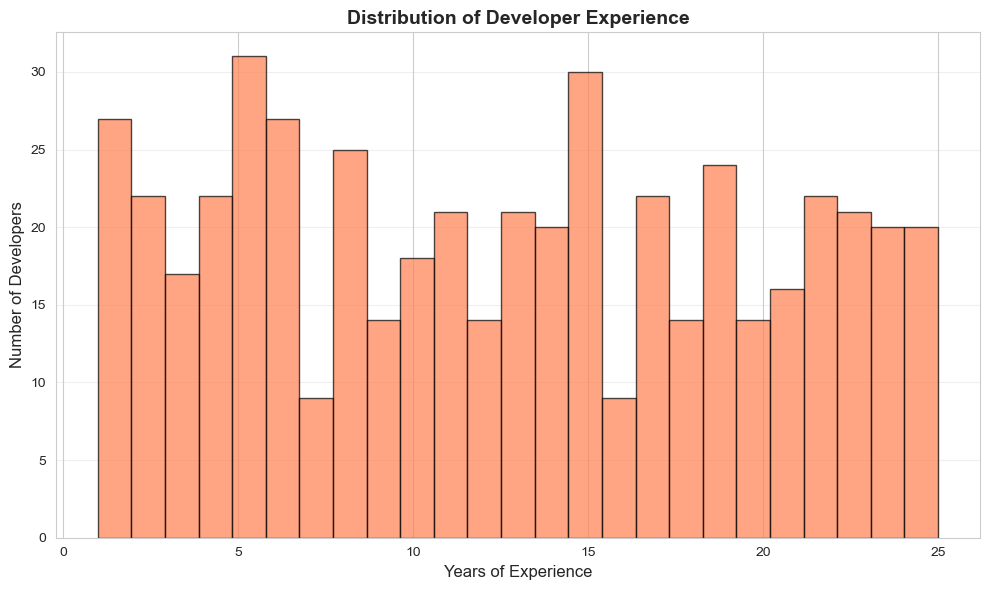

In [45]:
# Histogram of years of experience
plt.figure(figsize=(10, 6))
plt.hist(df['years_experience'], bins=25, color='coral', edgecolor='black', alpha=0.7)
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Number of Developers', fontsize=12)
plt.title('Distribution of Developer Experience', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Bar Plots: Comparing Categorical Variables

Bar plots are great for comparing counts or means across categories.


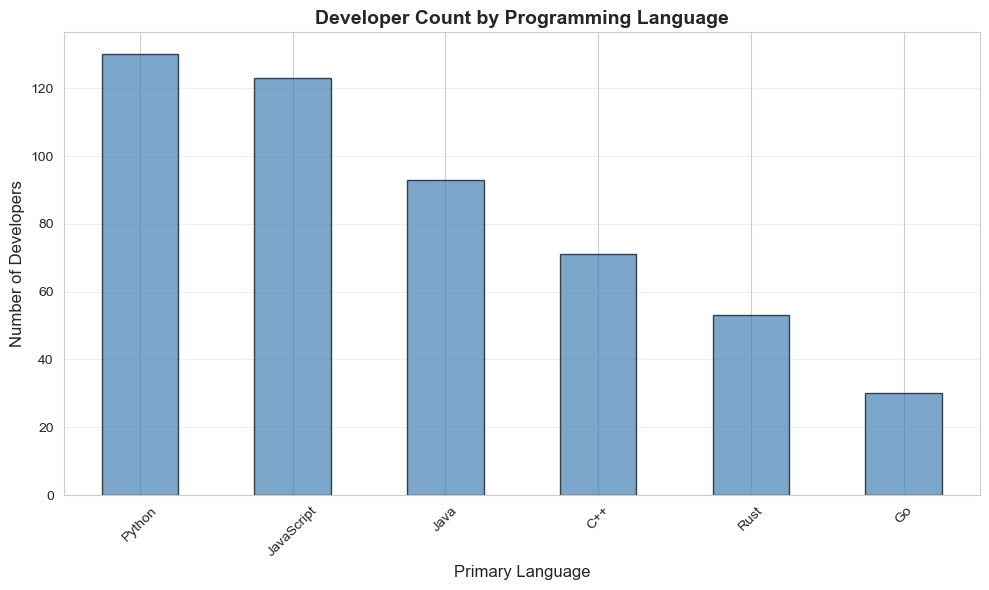

In [46]:
# Simple bar plot of language counts
language_counts = df['primary_language'].value_counts()
plt.figure(figsize=(10, 6))
language_counts.plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Primary Language', fontsize=12)
plt.ylabel('Number of Developers', fontsize=12)
plt.title('Developer Count by Programming Language', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

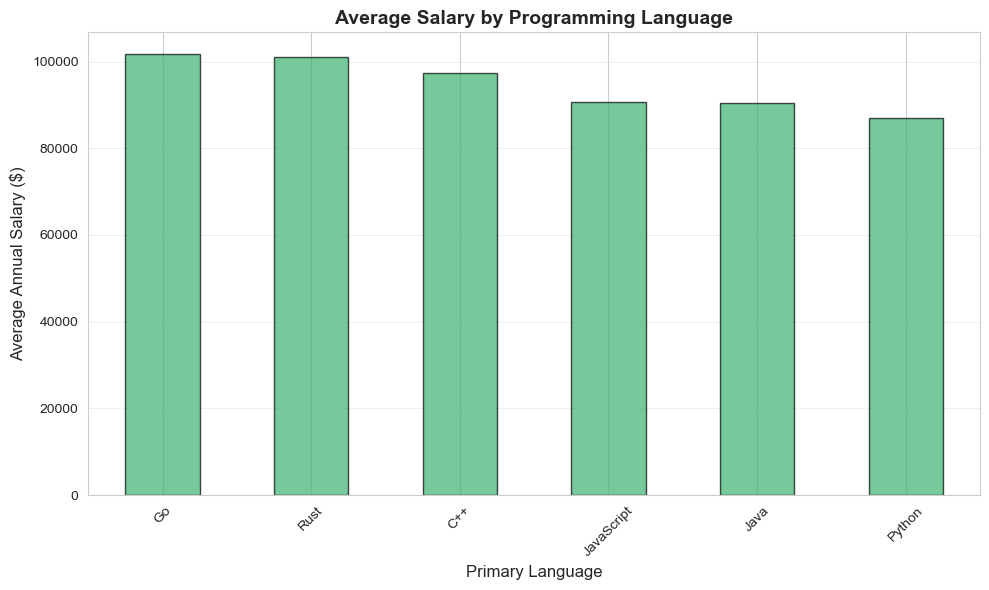

In [47]:
# Bar plot of average salary by language
avg_salary_by_lang = df.groupby('primary_language')['annual_salary'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
avg_salary_by_lang.plot(kind='bar', color='mediumseagreen', edgecolor='black', alpha=0.7)
plt.xlabel('Primary Language', fontsize=12)
plt.ylabel('Average Annual Salary ($)', fontsize=12)
plt.title('Average Salary by Programming Language', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Box Plots: Comparing Distributions Across Groups

Box plots show the median, quartiles, and outliers. Great for comparing distributions!

Reference: [seaborn.boxplot](https://seaborn.pydata.org/generated/seaborn.boxplot.html)


/var/folders/jk/pk02lhls259fnypkd7y6tbfw0000gn/T/ipykernel_69921/1863747298.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='company_size', y='annual_salary', palette='Set2')


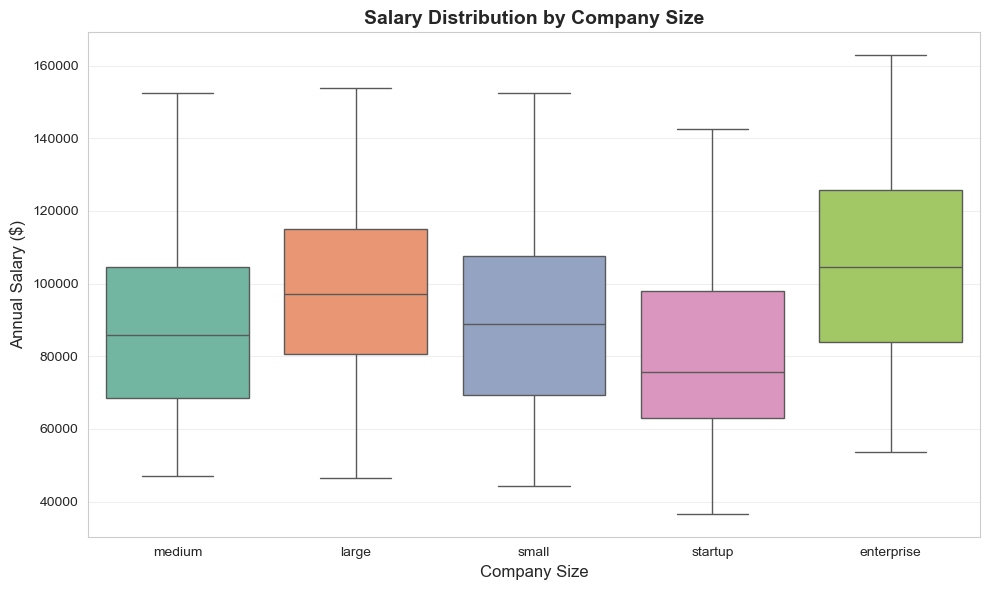

In [48]:
# Box plot of salary by company size
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='company_size', y='annual_salary', palette='Set2')
plt.xlabel('Company Size', fontsize=12)
plt.ylabel('Annual Salary ($)', fontsize=12)
plt.title('Salary Distribution by Company Size', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/jk/pk02lhls259fnypkd7y6tbfw0000gn/T/ipykernel_69921/187233481.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='experience_level', y='annual_salary', order=experience_order, palette='husl')


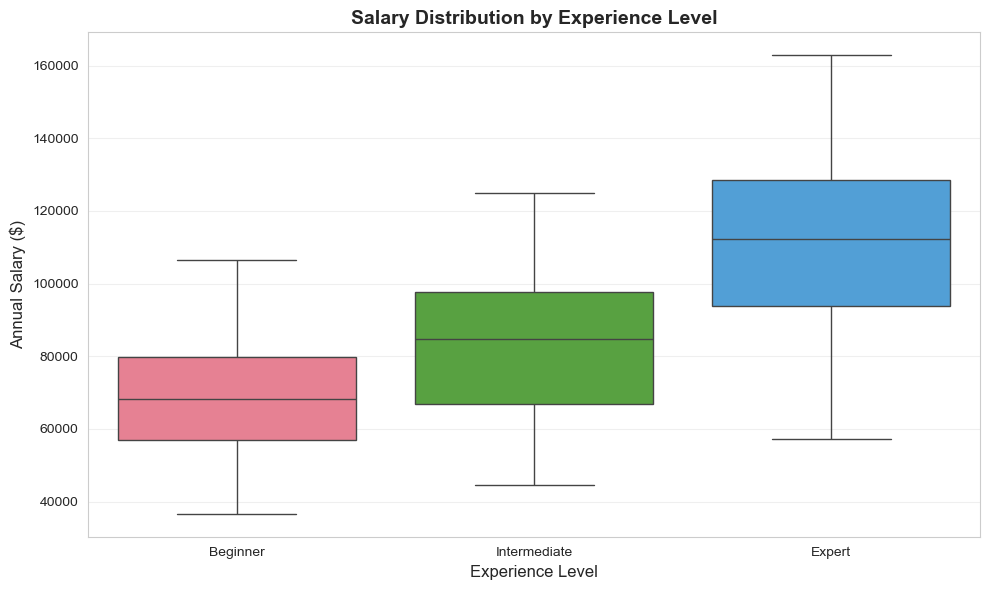

In [49]:
# Box plot of salary by experience level
# First, order the experience levels logically
experience_order = ['Beginner', 'Intermediate', 'Expert']
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='experience_level', y='annual_salary', order=experience_order, palette='husl')
plt.xlabel('Experience Level', fontsize=12)
plt.ylabel('Annual Salary ($)', fontsize=12)
plt.title('Salary Distribution by Experience Level', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Scatter Plots: Relationships Between Two Numerical Variables

Scatter plots show if two variables are related.


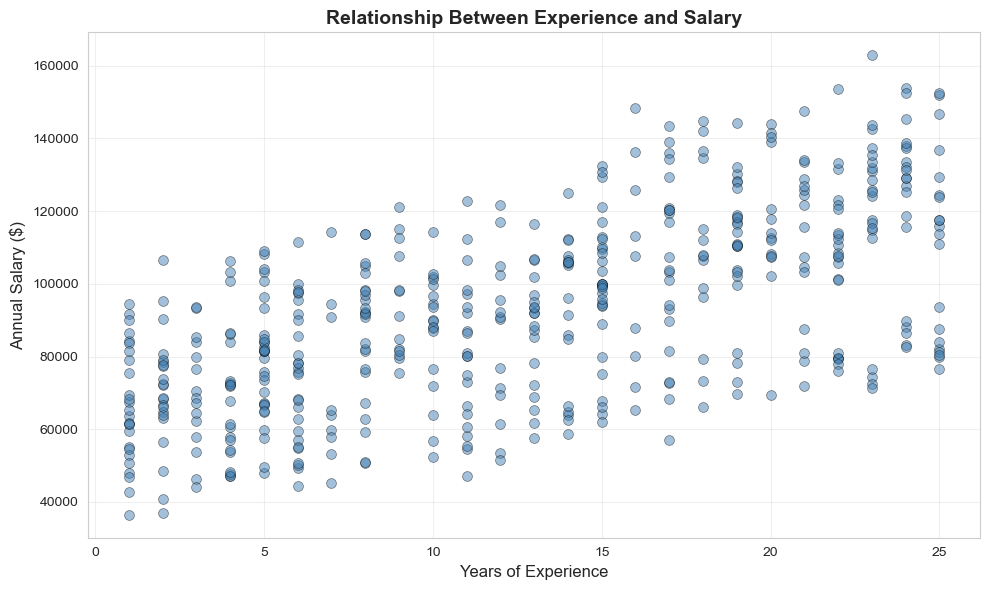

In [50]:
# Scatter plot: experience vs salary
plt.figure(figsize=(10, 6))
plt.scatter(df['years_experience'], df['annual_salary'], alpha=0.5, s=50, color='steelblue', edgecolor='black', linewidth=0.5)
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Annual Salary ($)', fontsize=12)
plt.title('Relationship Between Experience and Salary', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

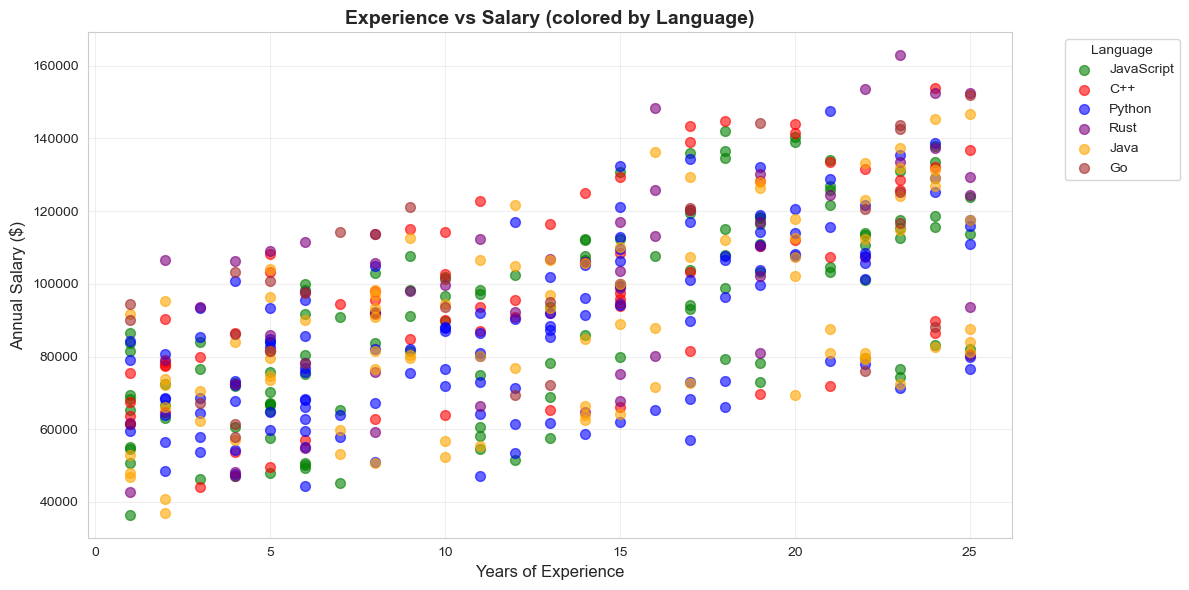

In [51]:
# Scatter plot with color coding for a third variable
languages = df['primary_language'].unique()
colors = {'Python': 'blue', 'Java': 'orange', 'JavaScript': 'green', 'C++': 'red', 'Rust': 'purple', 'Go': 'brown'}

plt.figure(figsize=(12, 6))
for lang in languages:
    mask = df['primary_language'] == lang
    plt.scatter(df[mask]['years_experience'], df[mask]['annual_salary'], 
               label=lang, alpha=0.6, s=50, color=colors.get(lang, 'gray'))

plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Annual Salary ($)', fontsize=12)
plt.title('Experience vs Salary (colored by Language)', fontsize=14, fontweight='bold')
plt.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### EXERCISES: Section 4

**Exercise 4.1:** Create a histogram of job satisfaction scores. What does the distribution look like?


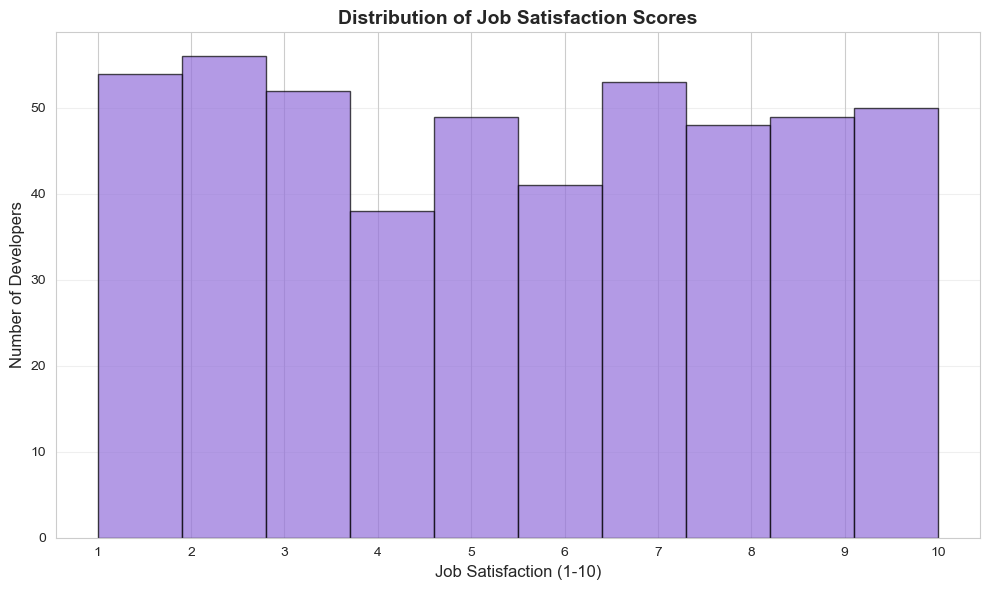


The distribution appears fairly uniform, with satisfaction scores spread across 1-10.


In [52]:
# Solution
plt.figure(figsize=(10, 6))
df['job_satisfaction'].dropna().hist(bins=10, color='mediumpurple', edgecolor='black', alpha=0.7)
plt.xlabel('Job Satisfaction (1-10)', fontsize=12)
plt.ylabel('Number of Developers', fontsize=12)
plt.title('Distribution of Job Satisfaction Scores', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

print(f"\nThe distribution appears fairly uniform, with satisfaction scores spread across 1-10.")


**Exercise 4.2:** Create a box plot comparing job satisfaction across different remote work statuses (yes, no, hybrid). What do you observe?


/var/folders/jk/pk02lhls259fnypkd7y6tbfw0000gn/T/ipykernel_69921/2568060184.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='remote_work', y='job_satisfaction', palette='husl')


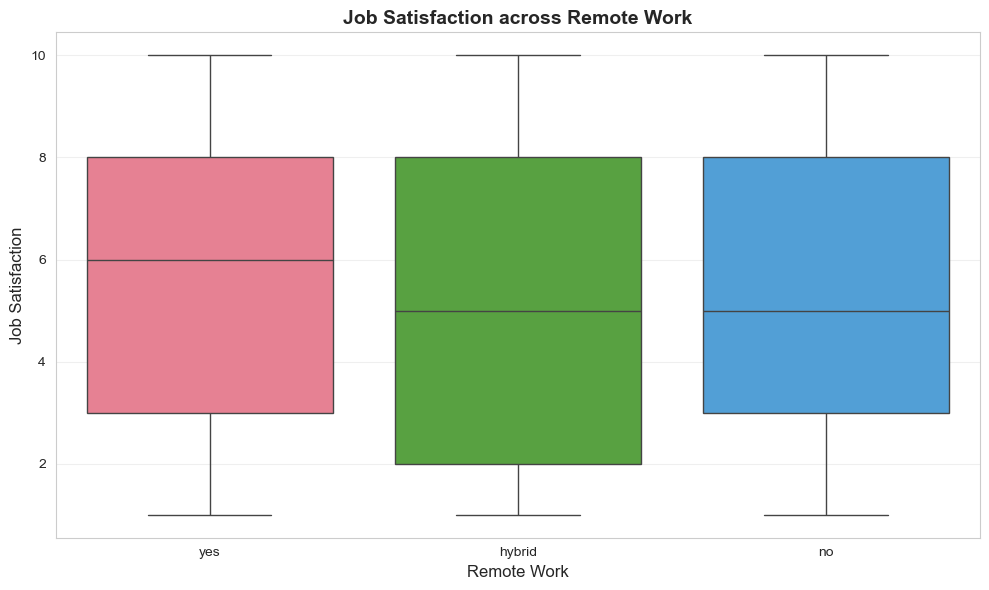

In [53]:
# Box plot of salary by experience level
# First, order the experience levels logically
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='remote_work', y='job_satisfaction', palette='husl')
plt.xlabel('Remote Work', fontsize=12)
plt.ylabel('Job Satisfaction', fontsize=12)
plt.title('Job Satisfaction across Remote Work', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Exercise 4.3:** Create a scatter plot showing the relationship between weekly hours worked and annual salary. Color the points by experience level. What pattern do you see?


In [54]:
# Your code here

---

## Wrap-Up

Congratulations! You've just learned the fundamental Python skills for data analysis:

1. **Loading & Exploring Data** — `pd.read_csv()`, `.head()`, `.describe()`, column/row selection
2. **Filtering & Transforming** — Boolean masks, `.apply()`, handling missing values
3. **Data Summaries** — `.mean()`, `.median()`, `.groupby()`, `.value_counts()` (connecting to lecture concepts)
4. **Visualization** — histograms, bar plots, box plots, scatter plots

These are the **exact techniques** that data scientists use every day. Next week, you'll go deeper and learn about statistical inference!

### Key Takeaways
- Data is stored in DataFrames (rows and columns)
- You can filter, transform, and summarize data with a few lines of code
- Visualization is crucial for understanding patterns
- Missing data is common — know how to handle it
- Group operations let you compare different subsets of data
